# Pos processing with geometric data.


In [7]:
using ComponentArrays
using Distributions
#using WGLMakie
using Lux
using LuxCUDA
using Flux
using OptimizationOptimJL
using Random
using UnPack
using Zygote
#using CairoMakie  # Backend que funciona en notebooks
using StatsBase
using Revise
using JLD2
using Plots
using LinearAlgebra
#import NaNMath



I put some functions here.

In [8]:
includet("../../neural_tools.jl")
includet("wave_ini_bound_data.jl")

┌ Warning: The use of `Flux.@functor` is deprecated.
│ Most likely, you should write `Flux.@layer MyLayer`which will add various convenience methods for your type,such as pretty-printing and use with Adapt.jl.
│ However, this is not required. Flux.jl v0.15 uses Functors.jl v0.5,which makes exploration of most nested `struct`s opt-out instead of opt-in...so Flux will automatically see inside any custom struct definitions.
│ If you really want to apply the `@functor` macro to a custom struct, use `Functors.@functor` instead.
└ @ Flux /Users/reula/.julia/packages/Flux/uRn8o/src/deprecations.jl:101


In [9]:
@load "wave_dirichlet_1D_geo_u0_sin_u1_zero_p8_BB.jld2" Θ_cpu st config losses #u0 u1 

NN = create_chain(config)

get_parameter_count(config)

config[:N_rounds]*config[:iters_per_round]

40000

In [ ]:
# -------------------------------------------------------------------
# Second order wave equation (onda 1D): u_tt - c^2 u_xx = 0
# -------------------------------------------------------------------
#wave_equation(∂2u_∂x2, ∂2u_∂t2, c) = ∂2u_∂t2 .- (c^2) .* ∂2u_∂x2

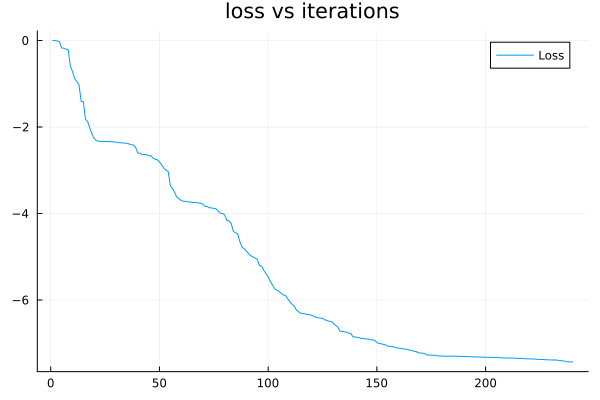

In [10]:
plot(losses, label = "Loss", title = "loss vs iterations")


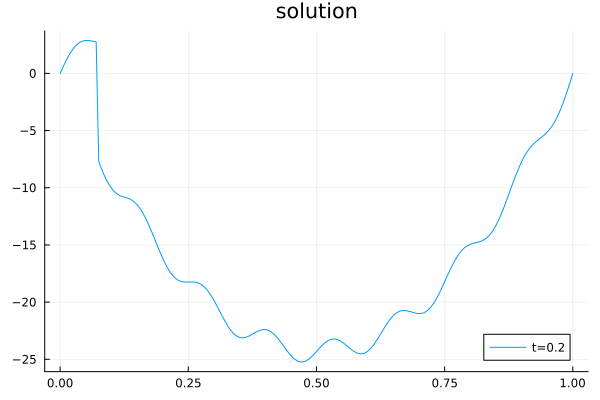

In [14]:
@unpack xmin, xmax, p, A = config

t = 0.2 #config[:tmax]
xs = reshape(collect(range(config[:xmin], config[:xmax], length=200)), 1, :)
t_fix = reshape(fill(t, length(xs)), 1, :)
#sol_p = [calculate_Dirichlet_f(xs, t_fix, NN, Θ, st) for x in xs]
sol_p = [calculate_Dirichlet_f_wf_geo(xs[:,i], t_fix[:,i], NN, Θ_cpu, st)[1] for i in 1:length(xs[1,:])]


plot(xs[1,:],sol_p, label = "t=$t", title = "solution")
#plot!(xs[1,:],config[:A]*(xs[1,:] .- config[:xmin]).^4 .* (xs[1,:] .- config[:xmax]).^4/((config[:xmax]-config[:xmin])/2)^8, label = "initial condition", linestyle = :dash)     


In [ ]:
sol_A = 

The error looks like a polynomial of order 10.

In [ ]:
plot(title = "solution")
t = 2.0
xs = reshape(collect(range(config[:xmin], config[:xmax], length=200)), 1, :)
t_fix = reshape(fill(t, length(xs)), 1, :)
#sol_p = [calculate_Dirichlet_f(xs, t_fix, NN, Θ, st) for x in xs]
sol_p = [calculate_Dirichlet_f(xs[:,i], t_fix[:,i], NN, Θ, st)[1] for i in 1:length(xs[1,:])]

plot!(xs[1,:],sol_p .- (config[:A]*(xs[1,:] .+ config[:xmin]).^4 .* (xs[1,:] .- config[:xmax]).^4)*2^8, label = "t=0")
#lines!(xs[1,:],bump.(xs[1,:], config[:x0], config[:x1], config[:p], config[:A]), label = "initial condition")
#lines!(xs[1,:],sol_p .-config[:A]*(xs[1,:] .- config[:xmin]).^4 .* (xs[1,:] .- config[:xmax]).^4, label = "initial condition", linestyle = :dash)     


In [ ]:
norm(sol_p .- (config[:A]*(xs[1,:] .+ config[:xmin]).^4 .* (xs[1,:] .- config[:xmax]).^4)*2^8)/norm(config[:A]*(xs[1,:] .- config[:xmin]).^4 .* (xs[1,:] .- config[:xmax]).^4)/sqrt(length(xs[1,:]))

Norm Error = 0.02606418374105666, When loss = -3.5 

In [ ]:
norm([1,1,1])/sqrt(length([1,1,1]))

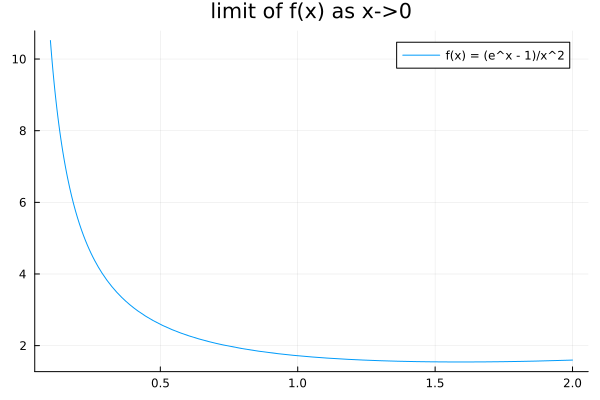

In [18]:
plot(x -> (exp(x) - 1)/x^2, 0.1, 2, label = "f(x) = (e^x - 1)/x^2", title = "limit of f(x) as x->0")

In [20]:
g_p(x) = exp(x)*(x-2) - 2

g_p (generic function with 1 method)

In [24]:


using Roots
find_zero(g_p, 1.2)

2.2177151057570903

In [39]:
h(x, alpha) = exp(x)*(-exp(-x - alpha) + 1)/x/(x+alpha)
h_p(x,alpha) = exp(0) - (1-exp(-x - alpha))*(1/x + 1/(x+alpha)) 

h_p (generic function with 1 method)

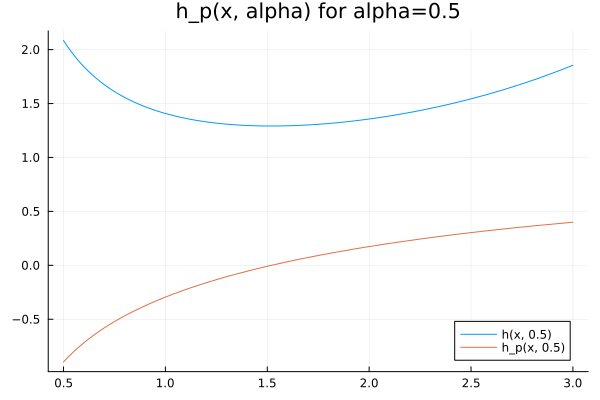

In [40]:
plot(x -> h(x, 0.5), 0.5, 3, label = "h(x, 0.5)", title = "h(x, alpha) for alpha=0.5")
plot!(x -> h_p(x, 0.5), 0.5, 3, label = "h_p(x, 0.5)", title = "h_p(x, alpha) for alpha=0.5")

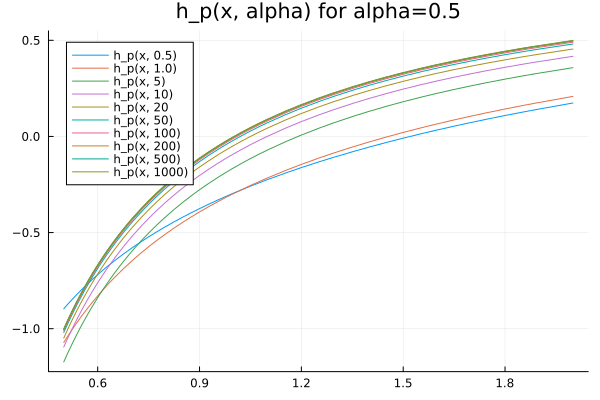

In [30]:
plot(x -> h_p(x, 0.5), 0.5, 2, label = "h_p(x, 0.5)", title = "h_p(x, alpha) for alpha=0.5")
plot!(x -> h_p(x, 1.0), 0.5, 2, label = "h_p(x, 1.0)")
plot!(x -> h_p(x, 5), 0.5, 2, label = "h_p(x, 5)")
plot!(x -> h_p(x, 10), 0.5, 2, label = "h_p(x, 10)")
plot!(x -> h_p(x, 20), 0.5, 2, label = "h_p(x, 20")
plot!(x -> h_p(x, 50), 0.5, 2, label = "h_p(x, 50)")
plot!(x -> h_p(x, 100), 0.5, 2, label = "h_p(x, 100)")
plot!(x -> h_p(x, 200), 0.5, 2, label = "h_p(x, 200)")
plot!(x -> h_p(x, 500), 0.5, 2, label = "h_p(x, 500)")
plot!(x -> h_p(x, 1000), 0.5, 2, label = "h_p(x, 1000)")

In [41]:
Y = [0.5, 1.0, 5, 10, 20, 50, 100, 200, 500, 1000]
c = zeros(length(Y))
for i in 1:length(Y)
    x0 = find_zero(x -> h_p(x, Y[i]), 1.5)
    c[i] = h(x0, Y[i])

end

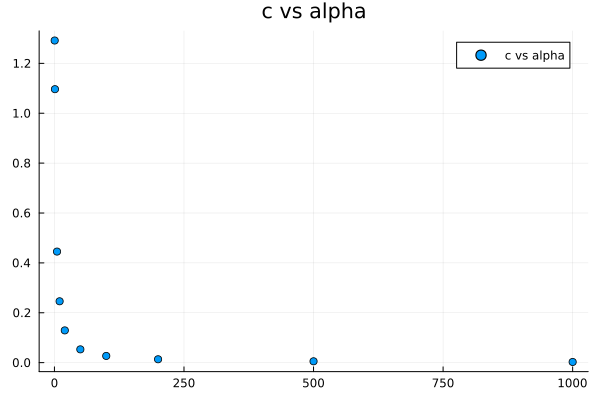

In [43]:
scatter(Y, c, label = "c vs alpha", title = "c vs alpha")